### Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("zomato.csv")
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


### Checking information of data 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [4]:
df.shape

(51717, 17)

In [5]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


### Check missing values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

dish_liked                     28078
rate                            7775
phone                           1208
approx_cost(for two people)      346
rest_type                        227
cuisines                          45
location                          21
listed_in(type)                    0
menu_item                          0
reviews_list                       0
url                                0
address                            0
votes                              0
book_table                         0
online_order                       0
name                               0
listed_in(city)                    0
dtype: int64


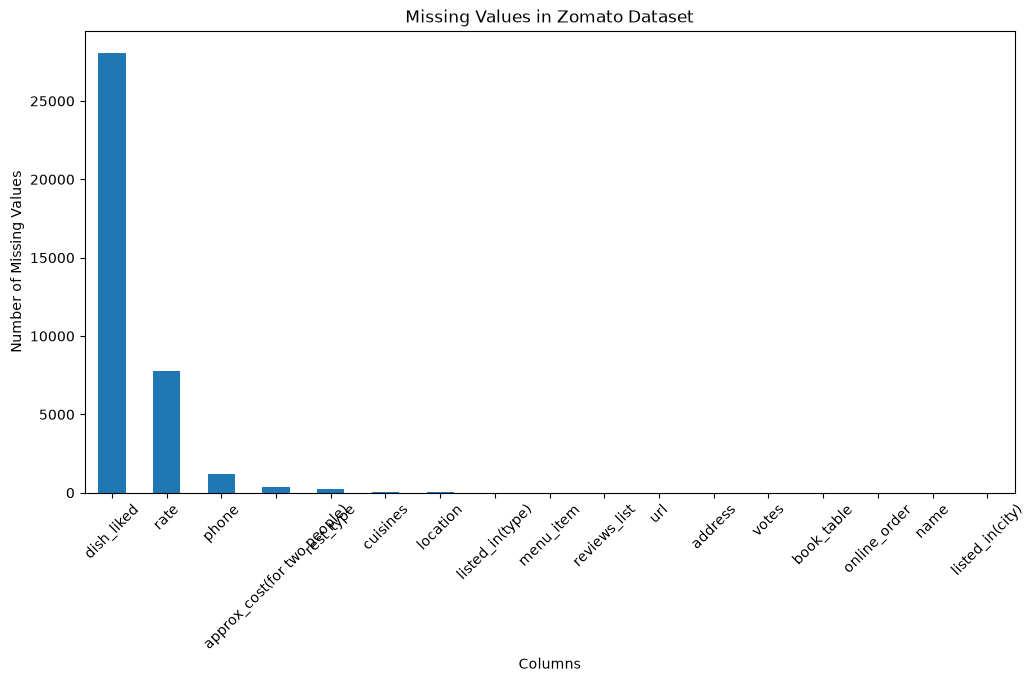

In [7]:
plt.figure(figsize=(12,6))

df.isnull().sum().sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values in Zomato Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

### Remove unnecessary columns

In [8]:
df = df.drop([
    'url',
    'address',
    'phone',
    'reviews_list',
    'menu_item'
], axis=1)

print(df.shape)

(51717, 12)


In [9]:
print(df['rate'].value_counts().head(20))

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1/5     1474
4.1 /5    1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
3.3 /5    1142
Name: count, dtype: int64


### Convert ratings to number

In [10]:
df['rate'] = df['rate'].astype(str).str.strip()

df['rate'] = df['rate'].replace({
    'NEW': np.nan,
    '-': np.nan,
    'nan': np.nan
})

df['rate'] = df['rate'].str.replace('/5', '', regex=False)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [11]:
print(df['rate'].head(10))

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
5    3.8
6    3.6
7    4.6
8    4.0
9    4.2
Name: rate, dtype: float64


In [12]:
print(df['rate'].dtype)

float64


### Check missing ratigs

In [13]:
print("Missing ratings:", df['rate'].isnull().sum())
print("Valid ratings:", df['rate'].notnull().sum())

Missing ratings: 10052
Valid ratings: 41665


### Remove row that are missing ratings

In [14]:
df = df.dropna(subset=['rate'])

print("Rows after removing missing ratings:", len(df))

Rows after removing missing ratings: 41665


### Clean resturant cost

In [15]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [16]:
print(df['approx_cost(for two people)'].head())
print(df['approx_cost(for two people)'].dtype)

0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
Name: approx_cost(for two people), dtype: float64
float64


### fill missing values

In [17]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [19]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64


### Rating Distribution

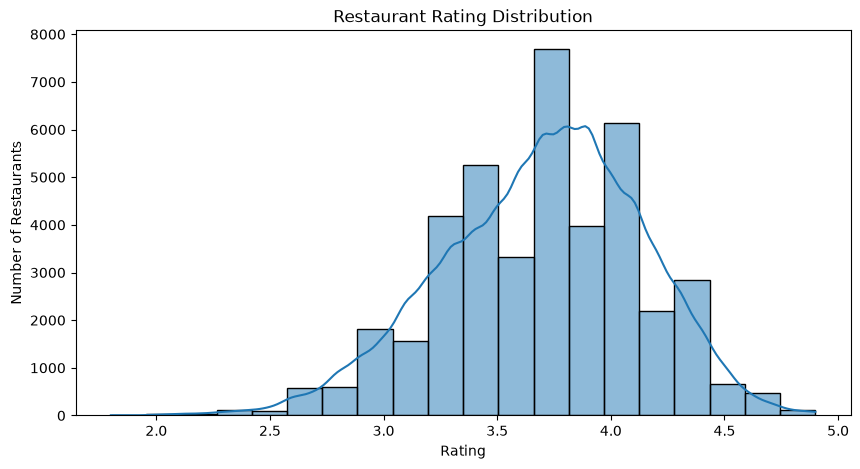

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['rate'], bins=20, kde=True)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

### Location Graph

### Top Resturants Locations

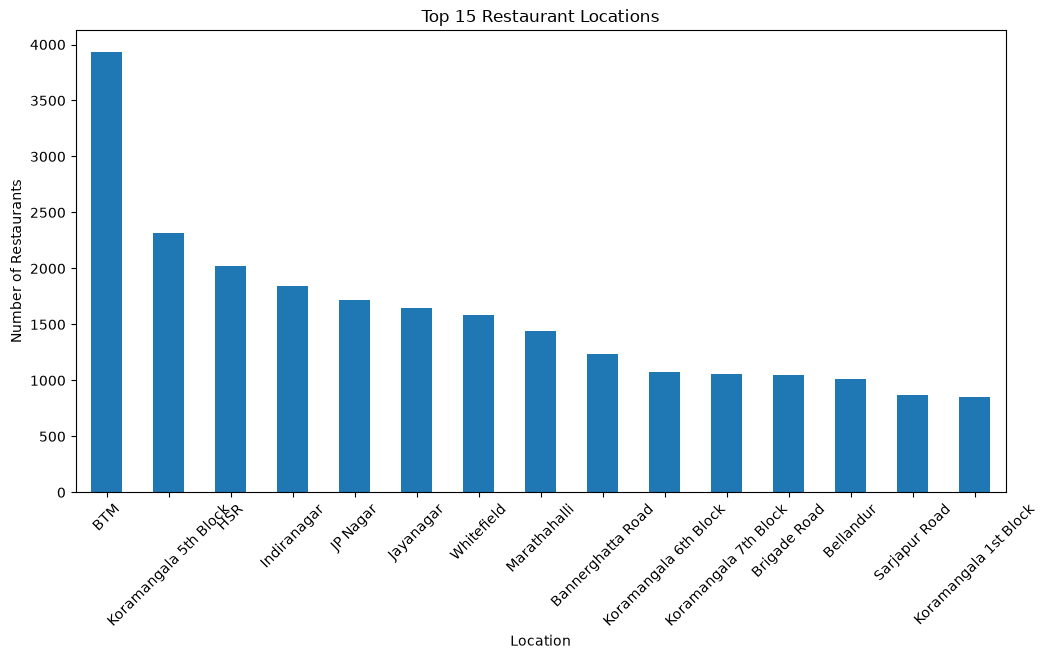

In [21]:
location_counts = df['location'].value_counts().head(15)

plt.figure(figsize=(12,6))

location_counts.plot(kind='bar')

plt.title("Top 15 Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

### Votes VS Ratings

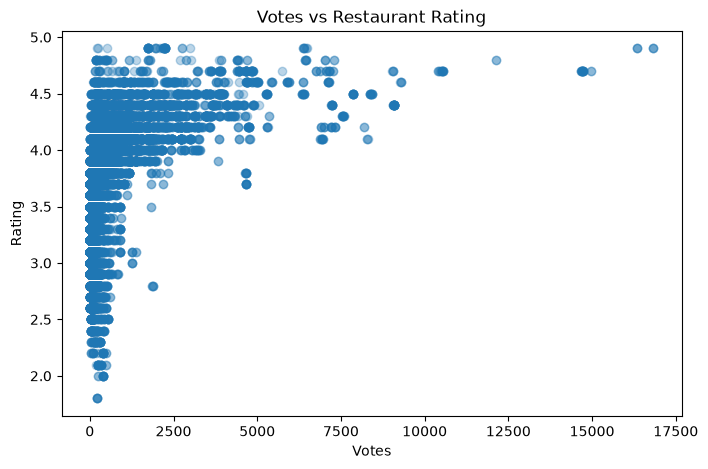

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df['votes'],df['rate'],alpha=0.3)

plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Restaurant Rating")

plt.show()

### Convert Categorical Values

In [23]:
df.select_dtypes(include='object').columns

Index(['name', 'online_order', 'book_table', 'location', 'rest_type',
       'dish_liked', 'cuisines', 'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [24]:
features = [
    'online_order',
    'book_table',
    'votes',
    'location',
    'rest_type',
    'cuisines',
    'approx_cost(for two people)',
    'listed_in(type)',
    'listed_in(city)'
]

### create x and y 

In [25]:
x = df[features]

y = df['rate']

In [26]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (41665, 9)
y shape: (41665,)


### One-hot encode categorical features

In [27]:
x = pd.get_dummies(x, drop_first=True)

print("Number of features:", x.shape[1])

Number of features: 2598


### Train-test split

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (33332, 2598)
Testing data: (8333, 2598)


### Linear Regression model

In [30]:
lr_model = LinearRegression()

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

### Evaluation

In [38]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
-------------------
MAE: 0.19968991257010152
RMSE: 0.28641447058099356
R2 Score: 0.5759741887599608


### Decision Tree

In [32]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=15
)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

### Evaluation

In [39]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("-------------------")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree
-------------------
MAE: 0.18326957548863837
RMSE: 0.2764041719517564
R2 Score: 0.6050959669318752


### RandomForest Regressor

In [34]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

### Evalution

In [40]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
-------------------
MAE: 0.18053801078850323
RMSE: 0.2604424219043575
R2 Score: 0.6493887622118136


### Gradient Boosting

In [35]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

### Evaluation

In [36]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("-----------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting
-----------------
MAE : 0.20527720192537816
RMSE: 0.27870512401440745
R2 Score: 0.598493770334946


### Compare all models

In [41]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.199690,0.286414,0.575974
1,Decision Tree,0.183270,0.276404,0.605096
2,Random Forest,0.180538,0.260442,0.649389
3,Gradient Boosting,0.205277,0.278705,0.598494


### Visualize

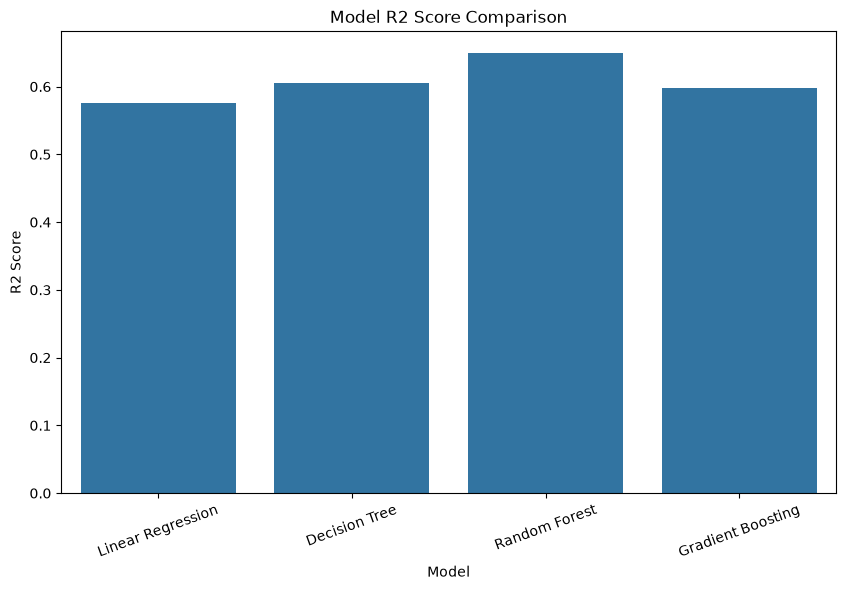

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model R2 Score Comparison")
plt.xticks(rotation=20)
plt.show()

### Actual vs Predicted Ratings

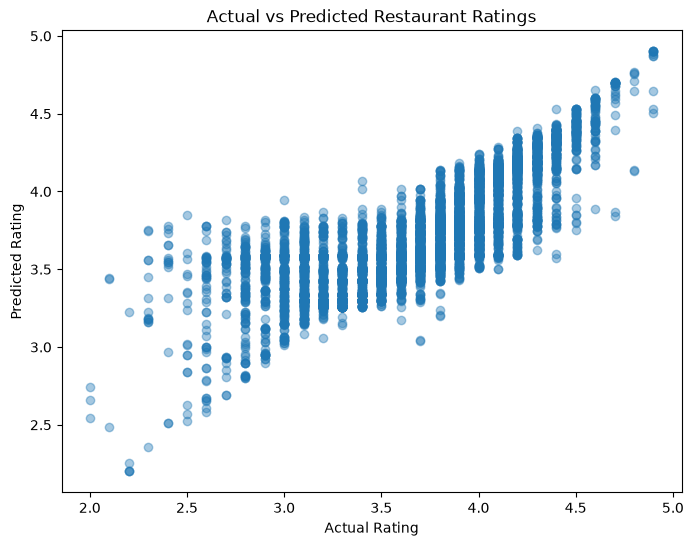

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.4
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.show()

### Feature Importance

In [40]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

importance

,Feature,Importance
0,votes,0.654520
1,approx_cost(for two people),0.035858
3,book_table_Yes,0.027538
131,rest_type_Dessert Parlor,0.021491
1842,"cuisines_North Indian, Chinese",0.017726
118,rest_type_Casual Dining,0.010602
110,rest_type_Cafe,0.008892
1702,cuisines_Mexican,0.008389
1987,"cuisines_North Indian, Continental, Chinese",0.005932
47,location_Koramangala 5th Block,0.005374


### Plot

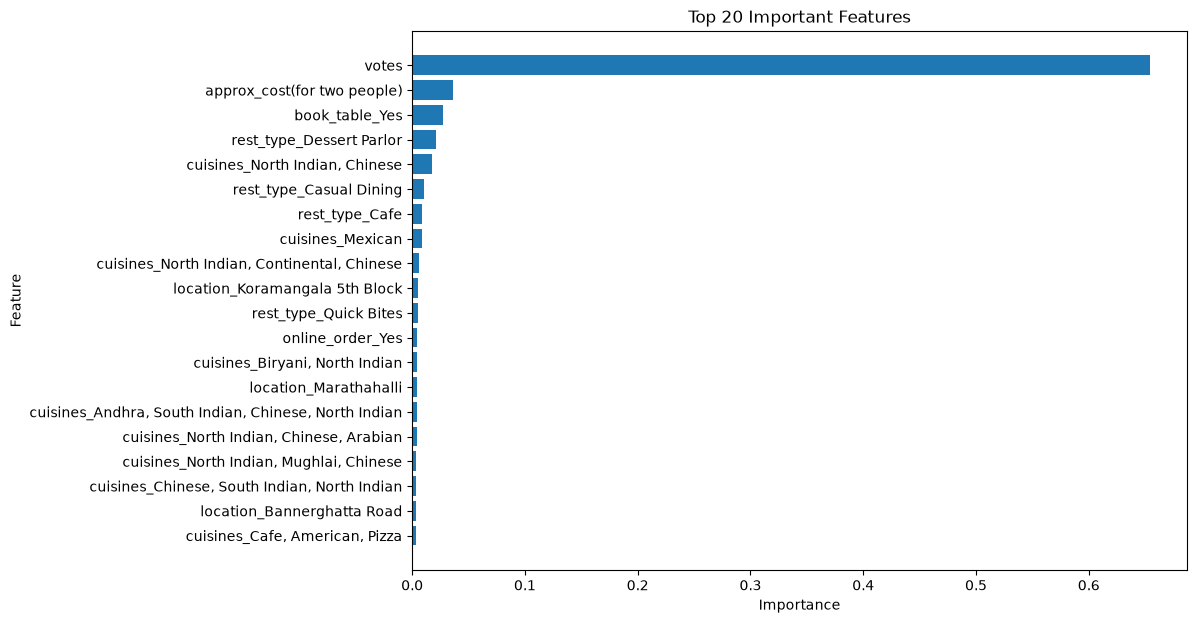

In [41]:
plt.figure(figsize=(10,7))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Test the model

In [42]:
sample = x_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Restaurant Rating:", round(prediction[0], 2))

Predicted Restaurant Rating: 4.23


### Comparing Rating 

In [43]:
actual = y_test.iloc[0]

print("Actual Rating:", actual)
print("Predicted Rating:", round(prediction[0], 2))

Actual Rating: 4.3
Predicted Rating: 4.23


### Saving The Model

In [44]:
import joblib

joblib.dump(rf_model, "zomato_rating_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [48]:
joblib.dump(x.columns.tolist(), "zomato_features.pkl")
print("Number of features:", len(x.columns))

Number of features: 2598


### Save your clean dataset 

In [47]:
df.to_csv("zomato_cleaned.csv", index=False)